### 타이타닉 생존자 예측 분석 실습

1. 필요한 라이브러리를 import
 https://seaborn.pydata.org/api.html

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('fivethirtyeight')  #print(plt.style.available) 스타일 바꾸기
plt.rcParams['font.family'] = 'Gulim'

import warnings #출력창에서 경고문구를 무시
warnings.filterwarnings('ignore')

%matplotlib inline 
#없어도 됨. 브라우저 안에 차트가 나오도록 하는 기능

### 2. 타이타닉 데이터를 가져오기

In [2]:
# seabon에서 제공하는 타이타닉 데이터를 가져와서 사용
d = sns.load_dataset('titanic')

In [3]:
d

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


### 3. 데이터의 구성 보기

In [ ]:
# 데이터의 컬럼별 정보 보기

d.info() 

survived : 생존여부(1: 생존, 0 : 사망)

pclass : 승선권 클래스(1 : 1등석, 2 : 2등석 ,3 : 3등석)

sex : 승객 성별

age : 승객 나이 

sibSp : 동반한 형제자매, 배우자 수

patch : 동반한 부모, 자식 수

fare 티켓의 요금

embarked : 승선한 항구명(C : Cherbourg, Q : Queenstown, S : Southampton)

class : 승선권 클래스(First: 1등석, Second: 2등석, Third: 3등석)

who: 남성, 여성, 어린이 구분 ( man, woman, child )

adult_male: 성인 남성 구분

deck: 갑판

embark_town: 승선한 항구명

alive: 생존 여부

alone: 동반자 유무(True일 때 동반자 없음)

In [ ]:
# 데이터의 개략적인 내용 살펴보기
d.head()

In [ ]:
d

### 4.생존자 집계

In [ ]:
d.groupby('alive').count()

In [ ]:
#전체 생존자 수 집계
d.groupby('alive')['alive'].count()

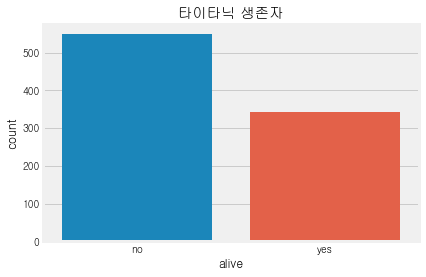

In [4]:
#전체 생존자 수를 막대 그래프로 표현
sns.countplot('alive',data=d)
plt.title('타이타닉 생존자')
plt.show()

### 5.  성별 생존자 수, 생존율

#### 5-1. 성별 생존자 수 (sex, alive)

In [ ]:
#성별 생존자 수
d.groupby(['sex','alive'])['alive'].count()

In [ ]:
#성별 생존자 수를 그래프로 확인
sns.countplot(x='sex',hue='alive', data=d)
#sns.countplot(y='sex',hue='alive', data=d)  y로 그리면 가로로 그려짐, hue도 칼럼명
plt.title('성별 생존자 수')
plt.show()

#### 5-2. 성별 생존율 (sex, survived)

In [ ]:
# 성별과 생존자수 데이터에서 
# 성별로 group 후 survived의 평균을 구하면 성별별 생존률을 구할 수 있다.

d[['sex','survived']].groupby('sex').mean()

In [ ]:
d.groupby('sex')['sex','survived'].mean()

In [ ]:
# barplot을 활용하여 남성보다 여성의 생존률이 높은 것을 시각적으로 확인
# barplot :두 개의 변수로 중첩된 그룹화를 사용하여 수직 막대 세트를 그립니다.
plt.title('성별 생존율')
sns.barplot(data=d,x='sex',y='survived')
plt.show()

In [ ]:
### 6. 어린이/성인남자/성인여자 별 생존자수와 생존율 분석

#### 6-1. 어린이/성인남자/성인여자 별 생존자수와 생존율 (who, alive (survived))

In [ ]:
d.head(10)

In [ ]:
d[d['who']=="child"]

In [ ]:
d.groupby('who').count()

In [ ]:
#성별에 아이 여부를 포함하여 분석해보기 - who 컬럼 사용

f, ax = plt.subplots(1,2,figsize=(8,5))
sns.countplot('who',hue='alive', data=d, ax=ax[0])
ax[0].set_title('성별 생존자 (어린이 구분)')
ax[0].set_ylabel('명수')

sns.barplot(data=d,x='who',y='survived',ax=ax[1])
ax[1].set_title('성별 생존율(어린이 구분)')
plt.show()

#### 7-1. 승선한 좌석 등급별 생존자 수 (class, alive)

In [ ]:
#승선 클래스별 승선자 수
d.groupby('class').count()

In [ ]:
#승선 클래스별 생존자 수
d.groupby(['class','alive'])['alive'].count()

In [ ]:
f, ax = plt.subplots(1,2,figsize=(8,5))
sns.countplot('class',data=d, ax=ax[0])
ax[0].set_title('승선 등급별 승선자 수')
ax[0].set_xlabel('승선 등급')
ax[0].set_ylabel('명수')

sns.countplot('class',hue='alive',data=d, ax=ax[1])
ax[1].set_title('등급별 생존자 수')
ax[1].set_xlabel('승선 등급')
ax[1].set_ylabel('명수')
plt.show()

#### 7-2. 승선한 좌석 등급별 생존율 (class, survived)

In [ ]:
#승선 클래스별 생존율
d.groupby(['class'])['survived'].mean()

In [ ]:
sns.barplot(data=d,x='class',y='survived')
plt.xlabel('객실 등급')
plt.ylabel('생존율')
plt.title('등급별 생존율')
plt.show()


#### 7-3. 승선한 객실 등급별과 성별에 따른 생존율 (class, sex, survived)

In [ ]:
#승선 클래스, 성별별 생존율
d.groupby(['class','sex'])['survived'].mean()

In [ ]:
sns.barplot(data=d,x='class',y='survived', hue='sex')
plt.xlabel('객실 등급')
plt.ylabel('생존율')
plt.title('등급별 성별 생존율')
plt.show()

#### 7-4. 승선한 객실 등급별, 성인남성과 그외 생존율 (class, who, survived)

In [ ]:
#승선 클래스별 남성,여성,어린이 생존율
d.groupby(['class','who'])['survived'].mean()

In [ ]:
#승선 클래스별 성인남성 생존율 비교
d.groupby(['class','adult_male'])['survived'].mean()

In [ ]:
#승선 클래스, 성별에 따른 생존율을 시각화하여 표현

f, ax = plt.subplots(1,3,figsize=(10,4))
sns.barplot(data=d,x='class',y='survived', hue='sex',ax=ax[0])
ax[0].set_xlabel('객실 등급')
ax[0].set_ylabel('생존율')
ax[0].set_title('등급별 생존율')

sns.barplot(data=d,x='class',y='survived',hue='who',ax=ax[1])
ax[1].set_title('등급별 생존율(어린이 구분)')
ax[1].set_xlabel('객실 등급')
ax[1].set_ylabel('생존율')

sns.barplot(data=d,x='class',y='survived',hue='adult_male',ax=ax[2])
ax[2].set_title('등급별 생존율(성인 남성 vs 그외)')
ax[2].set_xlabel('객실 등급')
ax[2].set_ylabel('생존율')
plt.show()

#### 8. 나이별 생존자 수 (age , survived)
 - age 컬럼의 null 처리가 필요 

In [ ]:
d

In [ ]:
# age 컬럼에 null이 몇 개 포함되어 있는지 확인
d['age'].isnull().sum()

In [ ]:
temp=d[d['age'].isnull()]
temp

In [ ]:
# age 컬럼 전체 구성을 살펴보기
print('가장 많은 나이:',d['age'].max(),'살')
print('가장 어린 나이:',d['age'].min(),'살')
print('     평균 나이:',d['age'].mean(),'살')

In [ ]:
# null인 age에 적용할 적정한 값을 찾기
# null값을 같은 값으로 모두 채우기보다는 근접한 값으로 채우기 위해 who 컬럼의 평균 나이를 구한다.
d[['who','age']].groupby('who').mean()

In [ ]:
# null인 age의 값을 채우기
# who 컬럼에 따른 평균 나이로 null을 채운다.
d.loc[(d['age'].isnull())&(d['who']=='child'),'age'] = 6
d.loc[(d['age'].isnull())&(d['who']=='man'),'age'] = 33
d.loc[(d['age'].isnull())&(d['who']=='woman'),'age'] = 32

In [ ]:
# age 컬럼에 null이 몇 개 포함되어 있는지 다시 확인
d['age'].isnull().sum()

In [ ]:
# age 컬럼에 null이 포함되어 있는지 확인하는 다른 방법
d['age'].isnull().any() #하나라도 null이 있으면 True return

In [ ]:
# age 컬럼의 전체 구성을 다시 확인하면 null이 채워져서 평균 나이가 조금 바뀐 것을 확인할 수 있다.
print('가장 많은 나이:',d['age'].max(),'살')
print('가장 어린 나이:',d['age'].min(),'살')
print('     평균 나이:',d['age'].mean(),'살')

In [ ]:
d.groupby('age')['age'].count()

In [ ]:
d.groupby('age')['survived'].sum()

In [ ]:
# 나이별 승선자 수, 생존자 수를 시각화하여 표현
plt.figure(figsize=(10,5))
sns.lineplot(data=d.groupby('age')['age'].count(),label='승선자 수')
sns.lineplot(data=d.groupby('age')['survived'].sum(), label='생존자 수')
plt.xlabel("나이")
plt.ylabel("인원수")
plt.show()

In [ ]:
# 나이별 승선자 대비 생존자 수를 성인 남성과 그 외의 그룹으로 나누어 시각화하여 표현
f, ax = plt.subplots(2,1,figsize=(10,6))

adult_male=d[d['adult_male']].groupby('age')
sns.lineplot(data=adult_male['age'].count(), label='남성 승선자수',ax=ax[0])
sns.lineplot(data=adult_male['survived'].sum(),label='남성 생존자수',ax=ax[0])
ax[0].set_title('나이별 남성 승선자 수')
ax[0].set_xlabel('나이')
ax[0].set_ylabel('명수')

not_adult_male=d[~d['adult_male']].groupby('age')
sns.lineplot(data=not_adult_male['age'].count(), label='남성 외 승선자수',ax=ax[1])
sns.lineplot(data=not_adult_male['survived'].sum(),label='남성 외 생존자수',ax=ax[1])
ax[1].set_title('나이별 남성 외 승선자 수')
ax[1].set_xlabel('나이')
ax[1].set_ylabel('명수')
plt.show()